# Лабораторная работа №1. Вариант 12

В этой лабораторной работе решаются две задачи одномерной оптимизации.

1. Для рациональной функции нужно найти область определения, интервалы монотонности и точки экстремума.
2. Для многочлена четвёртой степени нужно численно найти минимум на отрезке методом деления отрезка пополам, то есть методом дихотомии.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

## Задача 1. Интервалы монотонности и экстремумы

Дана функция

$$
f(x)=\frac{1-x+x^2}{1+x-x^2}.
$$

Сначала ищем область определения. Так как функция рациональная, знаменатель не должен равняться нулю:

$$
1+x-x^2\ne0.
$$

Решаем уравнение $1+x-x^2=0$:

$$
x^2-x-1=0,
$$

$$
x_{1,2}=\frac{1\pm\sqrt5}{2}.
$$

Обозначим

$$
\alpha=\frac{1-\sqrt5}{2}\approx-0.618,
\qquad
\beta=\frac{1+\sqrt5}{2}\approx1.618.
$$

Тогда область определения:

$$
D(f)=\mathbb{R}\setminus\{\alpha,\beta\}.
$$

В точках $\alpha$ и $\beta$ функция не определена, значит там вертикальные асимптоты.

## Производная

Пусть

$$
u(x)=1-x+x^2=x^2-x+1,
\qquad
v(x)=1+x-x^2.
$$

Тогда

$$
u'(x)=2x-1,
\qquad
v'(x)=1-2x.
$$

По правилу производной частного:

$$
f'(x)=\frac{u'(x)v(x)-u(x)v'(x)}{v(x)^2}.
$$

После упрощения:

$$
f'(x)=\frac{2(2x-1)}{(1+x-x^2)^2}.
$$

Знаменатель положителен на всей области определения, потому что стоит квадрат. Значит знак производной определяется только выражением $2x-1$.

Критическая точка:

$$
2x-1=0 \Rightarrow x=\frac12.
$$

Если $x<\frac12$, производная отрицательная, функция убывает. Если $x>\frac12$, производная положительная, функция возрастает. Но интервалы надо разделить ещё и точками разрыва $\alpha$ и $\beta$.

In [2]:
def f1(x):
    return (1 - x + x**2) / (1 + x - x**2)

alpha = (1 - np.sqrt(5)) / 2
beta = (1 + np.sqrt(5)) / 2
x_min_1 = 1 / 2
f_min_1 = f1(x_min_1)

print(f"alpha = {alpha:.6f}")
print(f"beta = {beta:.6f}")
print(f"x_min = {x_min_1:.6f}")
print(f"f(x_min) = {f_min_1:.6f}")

alpha = -0.618034
beta = 1.618034
x_min = 0.500000
f(x_min) = 0.600000


## Ответ по первой части

Функция убывает на интервалах

$$
(-\infty,\alpha), \qquad (\alpha,\frac12).
$$

Функция возрастает на интервалах

$$
(\frac12,\beta), \qquad (\beta,+\infty).
$$

В точке $x=\frac12$ производная меняет знак с минуса на плюс, поэтому это точка локального минимума:

$$
x_{min}=\frac12,
\qquad
f(x_{min})=\frac35=0.6.
$$

Максимумов нет.

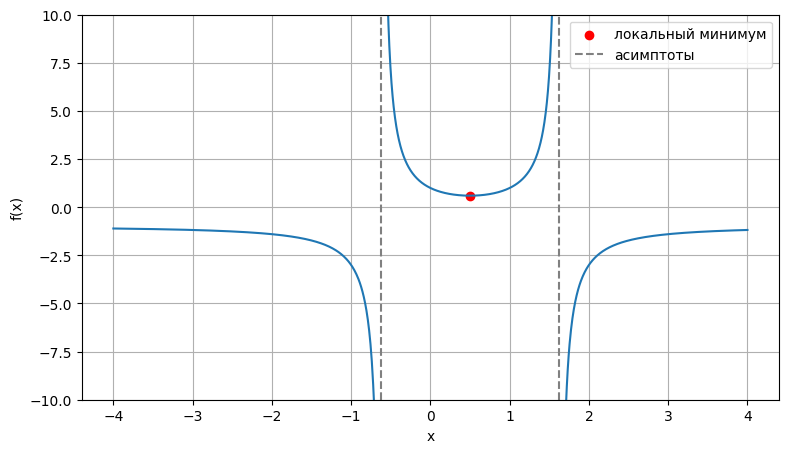

In [3]:
segments = [
    np.linspace(-4, alpha - 0.02, 400),
    np.linspace(alpha + 0.02, beta - 0.02, 800),
    np.linspace(beta + 0.02, 4, 400),
]

plt.figure(figsize=(9, 5))
for xs in segments:
    plt.plot(xs, f1(xs), color="C0")
plt.scatter([x_min_1], [f_min_1], color="red", label="локальный минимум")
plt.axvline(alpha, color="gray", linestyle="--", label="асимптоты")
plt.axvline(beta, color="gray", linestyle="--")
plt.ylim(-10, 10)
plt.grid(True)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.show()

## Задача 2. Метод деления отрезка пополам

Нужно найти минимум функции

$$
g(x)=\frac{x^4}{4}+x^2-8x+12
$$

на отрезке $[1,2]$ с точностью $\varepsilon=0.001$.

Проверим, что минимум на отрезке единственный. Производные:

$$
g'(x)=x^3+2x-8,
$$

$$
g''(x)=3x^2+2>0.
$$

Так как вторая производная всегда положительна, функция строго выпукла. Значит, минимум единственный. Кроме того,

$$
g'(1)=-5<0,
\qquad
 g'(2)=4>0,
$$

поэтому минимум находится внутри отрезка.

## Идея метода дихотомии

На каждой итерации берём две близкие точки около середины текущего отрезка:

$$
x_L=\frac{a+b-\delta}{2},
\qquad
x_R=\frac{a+b+\delta}{2}.
$$

Для минимума сравниваем $f(x_L)$ и $f(x_R)$:

- если $f(x_L)<f(x_R)$, минимум левее, поэтому сдвигаем правую границу;
- если $f(x_L)>f(x_R)$, минимум правее, поэтому сдвигаем левую границу;
- если значения равны, оставляем центральную часть.

Останавливаемся, когда длина отрезка стала меньше $\varepsilon$.

In [4]:
def dichotomy(func, a, b, eps):
    delta = eps / 2
    history = []
    iteration = 0

    while b - a > eps:
        x_left = (a + b - delta) / 2
        x_right = (a + b + delta) / 2
        f_left = func(x_left)
        f_right = func(x_right)

        old_a, old_b = a, b
        if f_left < f_right:
            b = x_right
        else:
            a = x_left

        iteration += 1
        history.append((iteration, old_a, old_b, x_left, x_right, f_left, f_right, a, b, b - a))

    x_star = (a + b) / 2
    return x_star, func(x_star), history

def g(x):
    return x**4 / 4 + x**2 - 8 * x + 12

x_star_1, f_star_1, history_1 = dichotomy(g, 1, 2, 0.001)
print(f"x* = {x_star_1:.9f}")
print(f"f* = {f_star_1:.9f}")
print(f"Количество итераций = {len(history_1)}")

x* = 1.670080933
f* = 3.373390631
Количество итераций = 11


In [5]:
for row in history_1:
    k, a, b, xl, xr, fl, fr, new_a, new_b, length = row
    print(f"{k:2d}: [{a:.6f}; {b:.6f}], xL={xl:.6f}, xR={xr:.6f}, "
          f"fL={fl:.6f}, fR={fr:.6f}, новый отрезок=[{new_a:.6f}; {new_b:.6f}], длина={length:.6f}")

 1: [1.000000; 2.000000], xL=1.499750, xR=1.500250, fL=3.516032, fR=3.515219, новый отрезок=[1.499750; 2.000000], длина=0.500250
 2: [1.499750; 2.000000], xL=1.749625, xR=1.750125, fL=3.406905, fR=3.407334, новый отрезок=[1.499750; 1.750125], длина=0.250375
 3: [1.499750; 1.750125], xL=1.624687, xR=1.625188, fL=3.383994, fR=3.383764, новый отрезок=[1.624687; 1.750125], длина=0.125438
 4: [1.624687; 1.750125], xL=1.687156, xR=1.687656, fL=3.374881, fR=3.374971, новый отрезок=[1.624687; 1.687656], длина=0.062969
 5: [1.624687; 1.687656], xL=1.655922, xR=1.656422, fL=3.374449, fR=3.374377, новый отрезок=[1.655922; 1.687656], длина=0.031734
 6: [1.655922; 1.687656], xL=1.671539, xR=1.672039, fL=3.373399, fR=3.373407, новый отрезок=[1.655922; 1.672039], длина=0.016117
 7: [1.655922; 1.672039], xL=1.663730, xR=1.664230, fL=3.373610, fR=3.373578, новый отрезок=[1.663730; 1.672039], длина=0.008309
 8: [1.663730; 1.672039], xL=1.667635, xR=1.668135, fL=3.373426, fR=3.373414, новый отрезок=[1.66

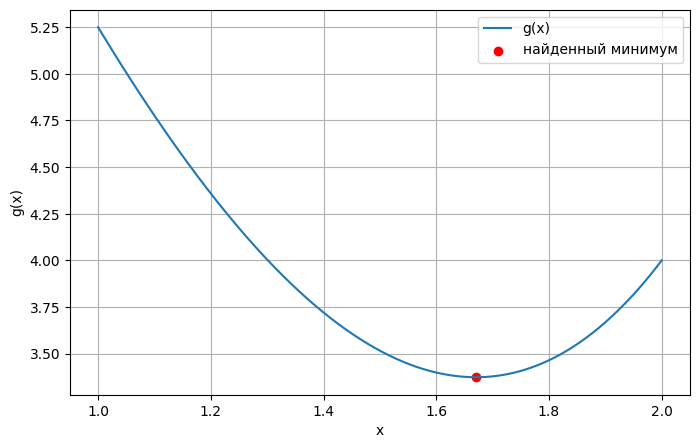

In [6]:
xs = np.linspace(1, 2, 500)
plt.figure(figsize=(8, 5))
plt.plot(xs, g(xs), label="g(x)")
plt.scatter([x_star_1], [f_star_1], color="red", label="найденный минимум")
plt.grid(True)
plt.xlabel("x")
plt.ylabel("g(x)")
plt.legend()
plt.show()

## Итог по лабораторной 1

1. Для рациональной функции нашли область определения и производную.
2. Производная равна

$$
f'(x)=\frac{2(2x-1)}{(1+x-x^2)^2}.
$$

3. Точка локального минимума первой функции:

$$
x=0.5,
\qquad
f(x)=0.6.
$$

4. Для второй функции методом дихотомии получили:

$$
x^*\approx1.67008,
\qquad
f^*\approx3.37339.
$$

5. Метод завершился за 11 итераций.
